# Email Classification Pipeline

A complete NLP pipeline that classifies emails into five categories —
**Spam, Important, Work, Promotion, Personal** — using three models:
Naive Bayes, SVM, and LSTM.

## Pipeline Overview
| Step | Description |
|------|-------------|
| 1 | Imports & setup |
| 2–4 | Raw parsing → cleaning → NLP preprocessing *(commented out — see note below)* |
| 5 | **Load `emails_final.csv`** ← start here |
| 6 | Exploratory Data Analysis |
| 7 | TF-IDF vectorisation |
| 8 | Train / test split |
| 9 | Shared evaluation helper |
| 10 | Naive Bayes |
| 11 | SVM (linear kernel) |
| 12 | LSTM (deep learning) |
| 13 | Results comparison |

> ⚠️ **Privacy Notice**  
> The original dataset (`emails_extracted.csv`) consists of **personal emails** and is
> not included in this repository for privacy and safety reasons.  
> Steps 2–4 show the full cleaning and preprocessing pipeline for transparency and
> reproducibility — uncomment them only if you supply your own raw CSV.  
> All modelling runs on `emails_final.csv`, which contains only anonymised token-level data.


## 0. Install Dependencies

In [7]:
# Install all third-party libraries needed throughout this notebook.
# The -q flag suppresses verbose output to keep things tidy.
%pip install -q emoji beautifulsoup4 wordcloud plotly nltk scikit-learn tensorflow seaborn


## 1. Imports

In [8]:
# ── Standard library ────────────────────────────────────────────────────────
import ast          # safely parse string representations of Python objects
import csv          # robust CSV reading (handles quoted newlines in fields)
import re           # regular expressions for text cleaning
import string       # convenient access to punctuation characters
import sys          # needed to raise the CSV field-size limit
import unicodedata  # Unicode normalisation (e.g. fancy quotes → plain quotes)

# ── Third-party ─────────────────────────────────────────────────────────────
import emoji                          # strip or replace emoji characters
import matplotlib.pyplot as plt       # static plots
import nltk                           # NLP toolkit
import numpy as np                    # numerical operations
import pandas as pd                   # DataFrames
import plotly.express as px           # quick interactive charts
import plotly.graph_objects as go     # lower-level interactive charts
import seaborn as sns                 # statistical heatmaps
from bs4 import BeautifulSoup         # HTML tag stripping
from nltk.corpus import stopwords     # common words to discard (the, is, …)
from nltk.stem import WordNetLemmatizer   # reduce words to their base form
from nltk.tokenize import word_tokenize  # split text into word tokens
from sklearn.feature_extraction.text import TfidfVectorizer  # TF-IDF features
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score,
    precision_score, recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB  # fast probabilistic classifier
from sklearn.svm import SVC                    # support-vector classifier
from wordcloud import WordCloud                # word-frequency visualisation

# Download required NLTK corpora and tokeniser models (only runs once).
for pkg in ['stopwords', 'punkt', 'punkt_tab', 'wordnet']:
    nltk.download(pkg, quiet=True)

print('All imports successful.')


All imports successful.


## 2. Raw Data Parsing *(commented out — raw CSV not available)*

This cell shows how the raw `emails_extracted.csv` was originally parsed.  
The raw email bodies contain embedded newlines and very large fields that break  
`pd.read_csv`, so we read line-by-line with Python's `csv` module instead.  
**Uncomment and run this cell only if you have the raw file.**


In [9]:
# ── RAW CSV PARSING ──────────────────────────────────────────────────────────
# Raw file not included — personal emails excluded for privacy.
# Uncomment everything below only if you have emails_extracted.csv.
# ─────────────────────────────────────────────────────────────────────────────

# RAW_CSV     = '/content/emails_extracted.csv'
# CLEANED_CSV = 'emails_extracted_text_cleaned.csv'

# # Email bodies can be extremely long. The default CSV field-size limit
# # is too small and causes a _csv.Error; removing the cap entirely.
# csv.field_size_limit(sys.maxsize)

# valid_lines, skipped = [], 0
# with open(RAW_CSV, 'r', encoding='utf-8') as f:
#     reader = csv.reader(f)
#     for row in reader:
#         try:
#             # Header defines 5 columns: id, from, subject, snippet, body.
#             # Rows with a different field count are malformed — skip them.
#             if len(row) == 5:
#                 valid_lines.append(row)
#             else:
#                 skipped += 1
#         except csv.Error:
#             skipped += 1   # row itself is unparseable

# print(f'Valid rows  : {len(valid_lines) - 1:,}')  # -1 for the header row
# print(f'Skipped rows: {skipped:,}')

# header, *data_rows = valid_lines
# df_raw = pd.DataFrame(data_rows, columns=header)
# print(df_raw.shape)
# df_raw.head(3)


## 3. Text Cleaning *(commented out — raw CSV not available)*

This cell shows the full deterministic `clean_text()` pipeline that was applied  
to produce the `emails_final.csv` you already have.  
**Uncomment and run this cell only if you ran Step 2 above.**

The pipeline per text column:
- Unicode normalisation (NFKC)
- Fix hyphenated / plain line-break word splits
- Lowercase → strip HTML → expand contractions
- Remove URLs, e-mails, numbers, punctuation → collapse whitespace


In [10]:
# ── TEXT CLEANING PIPELINE ───────────────────────────────────────────────────
# Uncomment everything below if you ran Step 2 (raw CSV parsing) above.
# ─────────────────────────────────────────────────────────────────────────────

# TEXT_COLS = ['subject', 'snippet', 'body']

# CONTRACTIONS = {
#     r"\bi[''']ll\b": 'i will',    r"\bwe[''']ll\b": 'we will',
#     r"\byou[''']ll\b": 'you will', r"\bhe[''']ll\b": 'he will',
#     r"\bshe[''']ll\b": 'she will', r"\bthey[''']ll\b": 'they will',
#     r"\bi[''']d\b": 'i would',    r"\bwe[''']d\b": 'we would',
#     r"\byou[''']d\b": 'you would', r"\bhe[''']d\b": 'he would',
#     r"\bshe[''']d\b": 'she would', r"\bthey[''']d\b": 'they would',
#     r"\bi[''']m\b": 'i am',        r"\bwe[''']re\b": 'we are',
#     r"\byou[''']re\b": 'you are',  r"\bhe[''']s\b": 'he is',
#     r"\bshe[''']s\b": 'she is',    r"\bit[''']s\b": 'it is',
#     r"\bthey[''']re\b": 'they are', r"\bcan[''']t\b": 'cannot',
#     r"\bwon[''']t\b": 'will not',  r"\bshan[''']t\b": 'shall not',
# }

# def fix_linebreak_splits(text):
#     """Re-join words split across lines by email clients."""
#     text = re.sub(r'(\w)-\n(\w)', r'\1\2', text)  # hyphenated line break
#     text = re.sub(r'(\w)\n(\w)',  r'\1\2', text)  # plain mid-word line break
#     return text.replace('\n', ' ')

# def clean_text(text):
#     """Full deterministic cleaning pipeline for a single text value."""
#     if pd.isna(text):
#         return None
#     text = unicodedata.normalize('NFKC', str(text))           # normalise unicode
#     text = fix_linebreak_splits(text)                          # fix line breaks
#     text = text.lower()                                        # lowercase
#     text = BeautifulSoup(text, 'lxml').get_text(' ')           # strip HTML
#     text = re.sub(r'(\w)\s*&\s*(\w)', r'\1and\2', text)       # normalise &
#     text = text.replace('&', ' and ')
#     for pattern, replacement in CONTRACTIONS.items():          # expand contractions
#         text = re.sub(pattern, replacement, text)
#     text = re.sub(r'http\S+|www\S+', ' ', text)               # remove URLs
#     text = re.sub(r'\S+@\S+',        ' ', text)               # remove emails
#     text = re.sub(r'\d+',            ' ', text)               # remove numbers
#     text = re.sub(r"[^a-zA-Z\s']",   ' ', text)               # remove punctuation
#     text = re.sub(r"'",              ' ', text)               # remove apostrophes
#     text = re.sub(r'\s+',            ' ', text).strip()       # collapse spaces
#     return text or None

# for col in TEXT_COLS:
#     df_raw[col] = df_raw[col].apply(clean_text).fillna('no_content')

# df_raw.to_csv(CLEANED_CSV, index=False, encoding='utf-8')
# print(f'Cleaned CSV saved → {CLEANED_CSV}')
# df_raw[TEXT_COLS].head(3)


## 4. NLP Preprocessing *(commented out — already done in emails_final.csv)*

This shows the tokenisation / stop-word removal / lemmatisation step that  
produced the `*_tokens` columns already present in `emails_final.csv`.  
**Uncomment only if re-running from a freshly cleaned CSV.**


In [11]:
# ── NLP PREPROCESSING ────────────────────────────────────────────────────────
# Uncomment if you need to regenerate token columns from a cleaned CSV.
# ─────────────────────────────────────────────────────────────────────────────

# lemmatizer = WordNetLemmatizer()
# stop_words  = set(stopwords.words('english'))  # set for O(1) lookup

# def process_text(text):
#     """Return a list of clean, lemmatised tokens from a raw text string.
#     Pipeline: strip HTML → lowercase → remove emojis → remove punct/digits
#               → tokenise → drop stop-words & single chars → lemmatise.
#     """
#     if pd.isna(text):
#         return []  # empty list is safe for all downstream operations
#     text = BeautifulSoup(str(text), 'html.parser').get_text(' ')  # strip HTML
#     text = text.lower()                                            # lowercase
#     text = emoji.replace_emoji(text, '')                           # remove emoji
#     text = re.sub(f'[{re.escape(string.punctuation)}]', '', text)  # remove punct
#     text = re.sub(r'\d+', '', text)                                # remove digits
#     text = re.sub(r'\s+', ' ', text).strip()                       # collapse spaces
#     tokens = word_tokenize(text)                                    # tokenise
#     tokens = [w for w in tokens if w not in stop_words and len(w) > 1]
#     return [lemmatizer.lemmatize(t) for t in tokens]               # lemmatise

# df['subject_tokens'] = df['subject'].apply(process_text)
# df['snippet_tokens'] = df['snippet'].apply(process_text)
# df['body_tokens']    = df['body'].apply(process_text)

# print('NLP preprocessing complete.')
# df[['subject_tokens', 'snippet_tokens', 'body_tokens']].head(3)


## 5. Load `emails_final.csv`

This is where execution **always starts** when running the notebook normally.  
The CSV already contains cleaned text, per-column token lists, combined text,  
and rule-based labels — everything produced by the commented-out steps above.


In [12]:
# ── MAIN ENTRY POINT ─────────────────────────────────────────────────────────
# Load the pre-processed dataset that already has token columns and labels.
# This is the output of the cleaning + NLP + labelling pipeline above.
FINAL_CSV = "/content/emails_final.csv"  # update path if running locally

df = pd.read_csv(FINAL_CSV)

# The token columns were saved as string representations of Python lists.
# ast.literal_eval converts them back to actual lists so we can iterate over them.
for col in ['body_tokens', 'subject_tokens', 'snippet_tokens']:
    df[col] = df[col].apply(ast.literal_eval)

# Quick sanity checks.
print(f'Shape   : {df.shape}')              # rows × columns
print(f'Columns : {list(df.columns)}')
print(f'Labels  : {df["label"].unique()}')
print(f'\nMissing values:\n{df.isnull().sum()}')
df.head(3)


Shape   : (5000, 7)
Columns : ['body_tokens', 'subject_tokens', 'snippet_tokens', 'label', 'combined_text', 'combined_tokens', 'combined_text_for_tokenizer']
Labels  : ['Important' 'Work' 'Promotion' 'Spam' 'Personal']

Missing values:
body_tokens                    0
subject_tokens                 0
snippet_tokens                 0
label                          0
combined_text                  0
combined_tokens                0
combined_text_for_tokenizer    0
dtype: int64


,body_tokens,subject_tokens,snippet_tokens,label,combined_text,combined_tokens,combined_text_for_tokenizer
0,"[image, google, allowed, email, classifier, te...","[security, alert]","[allowed, email, classifier, test, access, goo...",Important,image google allowed email classifier test acc...,"['security', 'alert', 'allowed', 'email', 'cla...",security alert allowed email classifier test a...
1,"[convert, document, markdown, hi, murtaza, bec...","[breaking, microsoft, launch, free, python, li...","[convert, document, markdown]",Work,convert document markdown hi murtaza becoming ...,"['breaking', 'microsoft', 'launch', 'free', 'p...",breaking microsoft launch free python library ...
2,"[email, intended, murtaza, majid, creative, da...","[murtaza, start, conversation, new, connection...","[see, muhammad, asif, connection, experience]",Promotion,email intended murtaza majid creative data sci...,"['murtaza', 'start', 'conversation', 'new', 'c...",murtaza start conversation new connection muha...


## 6. Exploratory Data Analysis

### 6.1 Label Distribution

In [13]:
# value_counts() returns a Series; reset_index() turns it into a DataFrame
# with columns 'label' and 'count', which px.bar can consume directly.
fig = px.bar(
    df['label'].value_counts().reset_index(),
    x='label', y='count',
    color='label',
    title='Email Label Distribution',
    labels={'label': 'Category', 'count': 'Count'},
)
fig.update_layout(showlegend=False)  # colour already distinguishes bars
fig.show()


### 6.2 Word Cloud (Email Bodies)

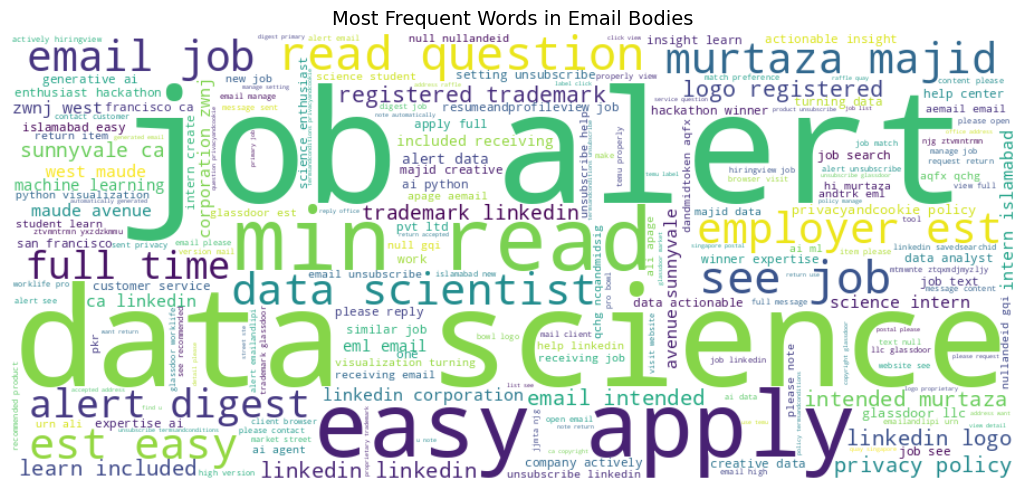

In [14]:
# Flatten the list-of-lists into a single flat list of tokens.
# We use body tokens because email bodies carry the richest vocabulary.
all_body_tokens = [token for tokens in df['body_tokens'] for token in tokens]

# WordCloud expects a single whitespace-separated string, not a list.
wc = WordCloud(width=900, height=400, background_color='white').generate(
    ' '.join(all_body_tokens)
)

plt.figure(figsize=(13, 5))
plt.imshow(wc, interpolation='bilinear')  # bilinear smooths the font edges
plt.axis('off')                           # hide axes — not meaningful here
plt.title('Most Frequent Words in Email Bodies', fontsize=14)
plt.tight_layout()
plt.show()


### 6.3 Top-30 Most Frequent Terms

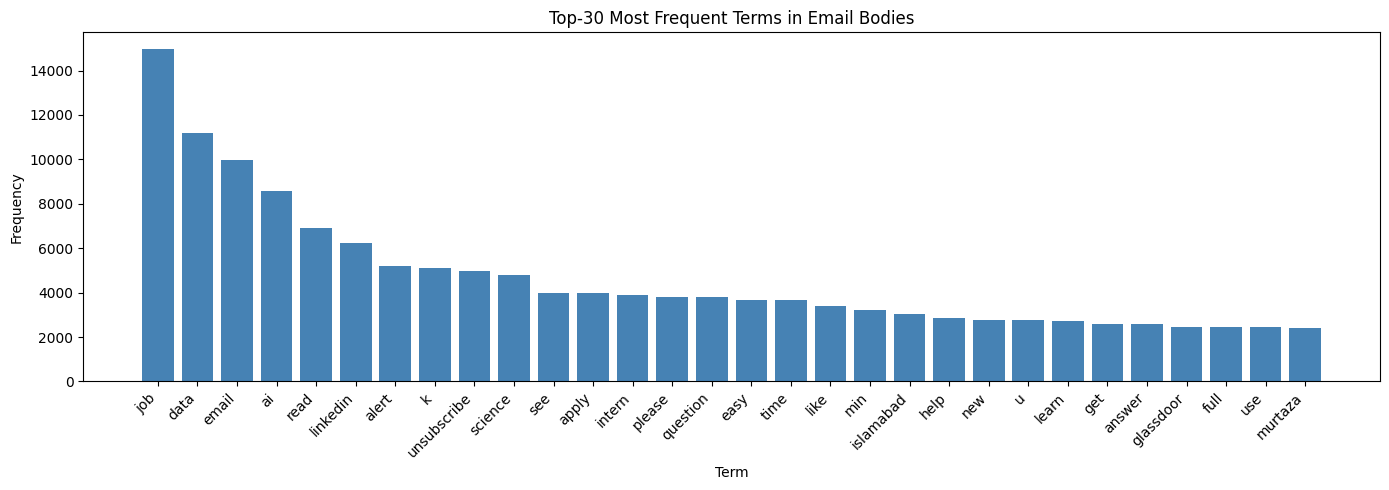

In [15]:
from nltk import FreqDist

# FreqDist counts occurrences of each unique token across the entire corpus.
fdist = FreqDist(all_body_tokens)

# most_common(30) returns [(token, count), ...] sorted by count descending.
# zip(*...) unpacks into two tuples: terms and their frequencies.
terms, freqs = zip(*fdist.most_common(30))

plt.figure(figsize=(14, 5))
plt.bar(terms, freqs, color='steelblue')
plt.xlabel('Term')
plt.ylabel('Frequency')
plt.title('Top-30 Most Frequent Terms in Email Bodies')
plt.xticks(rotation=45, ha='right')  # angle labels so they don't overlap
plt.tight_layout()                   # prevents x-labels being clipped
plt.show()


## 7. TF-IDF Vectorisation

Token lists from all three columns are joined into a single string per email  
and vectorised with `TfidfVectorizer(max_features=5000)`.  
The `combined_text` column already exists in the CSV so we use it directly.


In [16]:
# emails_final is the modelling-ready subset of df.
# We copy to avoid SettingWithCopyWarning on later assignments.
emails_final = df[['subject_tokens', 'snippet_tokens', 'body_tokens',
                    'combined_text', 'label']].copy()

# `combined_text` was pre-built during the pipeline and is already a plain
# whitespace-separated string — no further conversion needed.
# If it were missing we could rebuild it with:
#   emails_final['combined_text'] = emails_final.apply(
#       lambda r: ' '.join(r['subject_tokens'] + r['snippet_tokens'] + r['body_tokens']),
#       axis=1)

# TF-IDF (Term Frequency–Inverse Document Frequency) scores each token by how
# often it appears in a document relative to how rare it is across all documents.
# Common words like 'email' get a low score; distinctive words like 'bitcoin'
# get a high score. max_features=5000 caps the vocabulary to keep the matrix
# manageable while retaining the most informative tokens.
tfidf = TfidfVectorizer(max_features=5000)
tfidf_matrix = tfidf.fit_transform(emails_final['combined_text'])

# The result is a sparse matrix (rows=emails, cols=vocab tokens).
# Sparse storage is efficient because most emails only use a small fraction
# of the 5000 possible tokens, so most entries would be zero.
print('TF-IDF matrix shape:', tfidf_matrix.shape)


TF-IDF matrix shape: (5000, 5000)


## 8. Train / Test Split

In [17]:
X = tfidf_matrix          # feature matrix (sparse)
y = emails_final['label'] # target labels

# 80 / 20 split. stratify=y ensures each label's proportion is preserved
# in both sets — important when class sizes differ significantly.
# random_state=42 makes the split reproducible across runs.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]:,} samples')
print(f'Test : {X_test.shape[0]:,} samples')
print(f'\nClass distribution in train:\n{y_train.value_counts()}')


Train: 4,000 samples
Test : 1,000 samples

Class distribution in train:
label
Promotion    1557
Work         1536
Important     365
Spam          277
Personal      265
Name: count, dtype: int64


## 9. Evaluation Helper

A shared function used by all three models — prints metrics and plots the  
confusion matrix — so we don't repeat the same 20 lines three times.


In [18]:
def evaluate_model(y_true, y_pred, model_name, cmap='Blues'):
    """Compute and display key classification metrics plus a confusion matrix.

    Args:
        y_true      : Ground-truth labels.
        y_pred      : Model predictions.
        model_name  : String used in printed output and plot title.
        cmap        : Matplotlib colormap for the heatmap.

    Returns:
        Tuple of (accuracy, precision, recall, f1) so callers can store
        them for the final comparison table.

    Metric notes:
        Accuracy  — fraction of correct predictions overall.
        Precision — of all emails predicted as class X, how many actually are X?
        Recall    — of all actual class-X emails, how many did we catch?
        F1-score  — harmonic mean of precision and recall; balances both.
        average='weighted' weights each class by its support (number of true
        instances), accounting for class imbalance.
        zero_division=0 avoids warnings when a class has no predictions.
    """
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f'{model_name} Results')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall   : {rec:.4f}')
    print(f'  F1-score : {f1:.4f}')

    # Confusion matrix: rows = actual class, columns = predicted class.
    # A perfect model has all counts on the main diagonal.
    labels = sorted(set(y_true))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix — {model_name}')
    plt.tight_layout()
    plt.show()

    return acc, prec, rec, f1


## 10. Model 1 — Naive Bayes

Naive Bayes Results
  Accuracy : 0.7060
  Precision: 0.7276
  Recall   : 0.7060
  F1-score : 0.6988


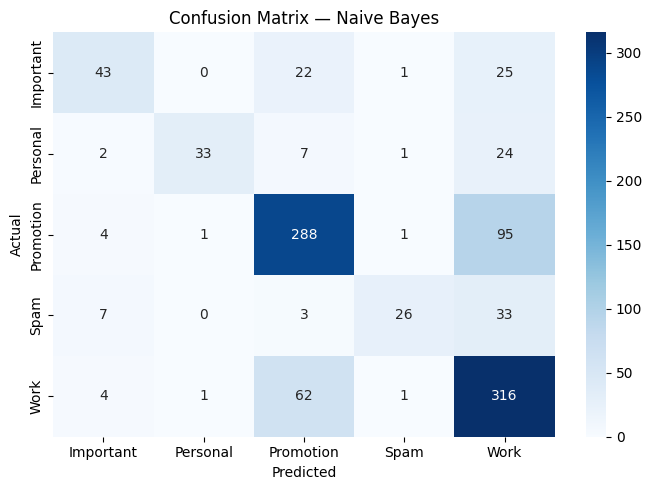

In [19]:
# Multinomial Naive Bayes is a natural fit for TF-IDF features because:
#   - It assumes features (word scores) are non-negative — TF-IDF satisfies this.
#   - It's very fast to train, even on large sparse matrices.
#   - Despite its 'naive' independence assumption it performs well on text.
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)
acc_nb, prec_nb, rec_nb, f1_nb = evaluate_model(
    y_test, y_pred_nb, 'Naive Bayes', cmap='Blues'
)


## 11. Model 2 — SVM (Linear Kernel)

SVM Results
  Accuracy : 0.7910
  Precision: 0.8003
  Recall   : 0.7910
  F1-score : 0.7853


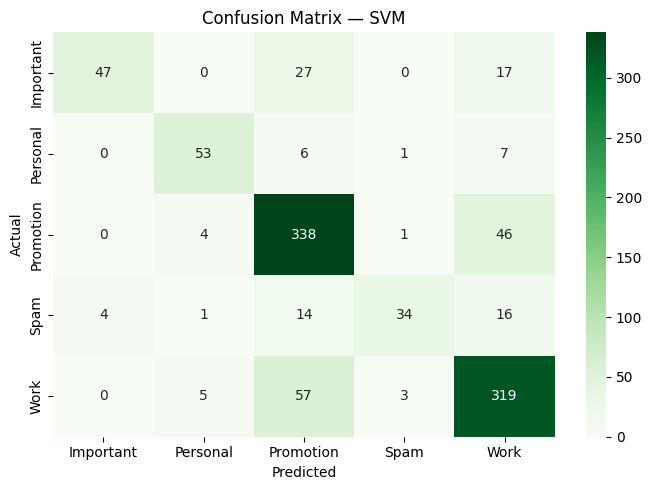

In [20]:
# SVM with a linear kernel works very well for high-dimensional sparse text
# features — it finds the maximum-margin hyperplane in the TF-IDF space.
# A linear kernel is preferred over rbf here: text data is usually linearly
# separable in high dimensions and training is significantly faster.
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)
acc_svm, prec_svm, rec_svm, f1_svm = evaluate_model(
    y_test, y_pred_svm, 'SVM', cmap='Greens'
)


## 12. Model 3 — LSTM

### 12.1 Install TensorFlow

In [21]:
# TensorFlow / Keras is only needed for the LSTM model.
# Installing it here (rather than at the top) avoids a slow install
# for users who only want to run the classical models above.
%pip install -q tensorflow


### 12.2 Prepare Sequences

In [22]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

# Maximum number of tokens to keep per email.
# Emails longer than this are truncated; shorter ones are zero-padded.
MAX_SEQ_LEN = 200

# Vocabulary size cap — only the top MAX_WORDS tokens are kept.
# Rarer tokens are mapped to the <OOV> (out-of-vocabulary) token.
MAX_WORDS   = 5000

# Fit the Keras Tokenizer on combined_text to build an integer vocabulary.
# Each unique token gets a unique integer ID (e.g. 'invoice' → 42).
tokenizer_lstm = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer_lstm.fit_on_texts(emails_final['combined_text'])

# Convert each email string to a sequence of integer token IDs.
sequences = tokenizer_lstm.texts_to_sequences(emails_final['combined_text'])

# Pad / truncate all sequences to the same fixed length so they can be batched.
# padding='post'    → zeros appended at the END of short sequences.
# truncating='post' → long sequences are cut from the END.
padded_sequences = pad_sequences(
    sequences, maxlen=MAX_SEQ_LEN, padding='post', truncating='post'
)

# The LSTM needs integer labels, not strings.
# Sorting the unique labels ensures the mapping is deterministic across runs.
label_mapping = {lbl: i for i, lbl in enumerate(sorted(emails_final['label'].unique()))}
print('Label mapping:', label_mapping)
y_lstm = emails_final['label'].map(label_mapping).values

# Same 80/20 stratified split as for the classical models.
X_lstm_train, X_lstm_test, y_lstm_train, y_lstm_test = train_test_split(
    padded_sequences, y_lstm, test_size=0.2, random_state=42, stratify=y_lstm
)
print(f'LSTM train: {X_lstm_train.shape},  test: {X_lstm_test.shape}')


Label mapping: {'Important': 0, 'Personal': 1, 'Promotion': 2, 'Spam': 3, 'Work': 4}
LSTM train: (4000, 200),  test: (1000, 200)


### 12.3 Build Model

In [23]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, Embedding, LSTM
from tensorflow.keras.models import Sequential

# vocab_size is +1 because Keras reserves index 0 for the padding token.
vocab_size    = len(tokenizer_lstm.word_index) + 1
embedding_dim = 100   # each token maps to a 100-dimensional dense vector
num_classes   = len(label_mapping)

model_lstm = Sequential([
    # Embedding: maps integer token IDs to dense vectors learned during training.
    # Similar words end up close together in the embedding space.
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=MAX_SEQ_LEN),

    # LSTM: processes the token sequence left-to-right, maintaining a hidden
    # state that captures context (e.g. 'not good' vs 'good').
    # return_sequences=False (default) — only the final hidden state is used.
    LSTM(128),

    # Hidden dense layer adds non-linear capacity before the output.
    Dense(64, activation='relu'),

    # Dropout randomly zeros 50% of neurons during training to reduce overfitting.
    Dropout(0.5),

    # Output: one neuron per class; softmax converts raw scores to probabilities.
    Dense(num_classes, activation='softmax'),
])

# sparse_categorical_crossentropy is used because our labels are integers
# (not one-hot encoded vectors).
model_lstm.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
model_lstm.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning:

Argument `input_length` is deprecated. Just remove it.



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 12.4 Train

In [24]:
# EarlyStopping monitors the validation loss and stops when it stops improving.
# patience=5  — allows 5 epochs without improvement before halting.
# restore_best_weights=True — rolls back to the epoch with the lowest val_loss,
# so we never keep an overfit checkpoint.
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# epochs=50 is a ceiling, not a target — EarlyStopping stops well before 50
# if the model converges. validation_split=0.1 holds out 10% of training data
# for validation without touching the held-out test set.
history = model_lstm.fit(
    X_lstm_train, y_lstm_train,
    epochs=50, batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1,
)
print('Training complete.')


Epoch 1/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 38s 311ms/step - accuracy: 0.4075 - loss: 1.3612 - val_accuracy: 0.4625 - val_loss: 1.2626
Epoch 2/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 24s 217ms/step - accuracy: 0.4542 - loss: 1.2782 - val_accuracy: 0.4750 - val_loss: 1.2217
Epoch 3/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 41s 213ms/step - accuracy: 0.5008 - loss: 1.2035 - val_accuracy: 0.5075 - val_loss: 1.2176
Epoch 4/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 25s 219ms/step - accuracy: 0.5267 - loss: 1.1293 - val_accuracy: 0.4950 - val_loss: 1.2318
Epoch 5/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 25s 222ms/step - accuracy: 0.5586 - loss: 1.0676 - val_accuracy: 0.4775 - val_loss: 1.2793
Epoch 6/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 24s 213ms/step - accuracy: 0.5694 - loss: 1.0334 - val_accuracy: 0.4900 - val_loss: 1.2338
Epoch 7/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 24s 213ms/step - accuracy: 0.5764 - loss: 1.0096 - val_accuracy: 0.4775 - val_loss: 1.3608
Epoch 8/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 24s 212ms/step - accuracy: 0.5803 - loss: 0

### 12.5 Evaluate

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step
LSTM Results
  Accuracy : 0.4710
  Precision: 0.5111
  Recall   : 0.4710
  F1-score : 0.4053


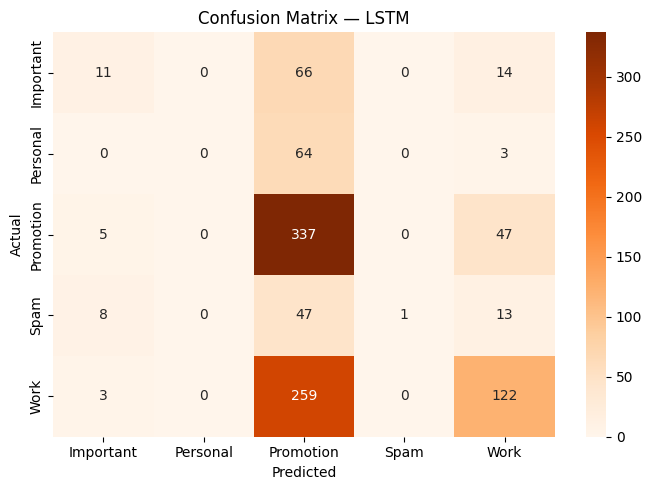

In [25]:
# predict() returns a probability array of shape (n_samples, num_classes).
# argmax picks the index of the highest probability — that is the predicted class.
y_pred_lstm_probs = model_lstm.predict(X_lstm_test)
y_pred_lstm_int   = np.argmax(y_pred_lstm_probs, axis=1)

# Convert integer indices back to human-readable label strings so the confusion
# matrix and metrics match the format used by Naive Bayes and SVM above.
reverse_mapping    = {v: k for k, v in label_mapping.items()}
y_pred_lstm_lbl    = [reverse_mapping[i] for i in y_pred_lstm_int]
y_test_lstm_lbl    = [reverse_mapping[i] for i in y_lstm_test]

acc_lstm, prec_lstm, rec_lstm, f1_lstm = evaluate_model(
    y_test_lstm_lbl, y_pred_lstm_lbl, 'LSTM', cmap='Oranges'
)


## 13. Results Comparison

Side-by-side summary of all three models.


In [26]:
# Collect all metrics into a single DataFrame for a clean side-by-side view.
results_df = pd.DataFrame({
    'Model'               : ['Naive Bayes', 'SVM', 'LSTM'],
    'Accuracy'            : [acc_nb,  acc_svm,  acc_lstm],
    'Precision (Weighted)': [prec_nb, prec_svm, prec_lstm],
    'Recall (Weighted)'   : [rec_nb,  rec_svm,  rec_lstm],
    'F1-score (Weighted)' : [f1_nb,   f1_svm,   f1_lstm],
})

print(results_df.round(4).to_string(index=False))

# Grouped bar chart — each group is one model, each bar is one metric.
# This makes it easy to see which model wins on each metric at a glance.
metrics = ['Accuracy', 'Precision (Weighted)', 'Recall (Weighted)', 'F1-score (Weighted)']
fig = go.Figure()
for metric in metrics:
    fig.add_trace(go.Bar(x=results_df['Model'], y=results_df[metric], name=metric))

fig.update_layout(
    barmode='group',
    title='Model Performance Comparison',
    xaxis_title='Model',
    yaxis_title='Score',
    yaxis=dict(range=[0, 1]),  # all metrics are between 0 and 1
    legend_title='Metric',
    template='plotly_white',
)
fig.show()


      Model  Accuracy  Precision (Weighted)  Recall (Weighted)  F1-score (Weighted)
Naive Bayes     0.706                0.7276              0.706               0.6988
        SVM     0.791                0.8003              0.791               0.7853
       LSTM     0.471                0.5111              0.471               0.4053
